In [1]:
%load_ext autoreload
%autoreload 2

import os
import logging
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm


from src.visualization.plot_slices import plot_slices
from src.config_presets.tools.get_config import get_config
from src.utils.move_batch_to_device import move_batch_to_device
from src.constants import DEVICE
from src.training.train import train
from src.training.validate import validate
from src.dataset.load_dataset import load_dataset, generate_K_fold_cross_validation_splits
from src.models.tools.get_classification_model import get_classification_model
from src.dataset.get_dataloader import make_dataloader   
from src.dataset.get_transforms import get_transforms
from src.utils.loss_func.get_loss_function import get_loss_function
from src.utils.saving.saving_predictions import concatenate_predictions, save_predictions
from src.utils.saving.create_results_directory import create_results_directory
from src.utils.list_dicts import append_to_list_dicts

from src.dataset.transforms.MixUp import MixUp


c:\Users\macraedc\AppData\Local\miniconda3\envs\HNC_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
config = get_config('Multi_tox_MIXUP')
config['training']['batch_size'] = 2
config['data']['augmentation']['mixup']['isEnabled'] = False
config['data']['dataloader']['dataset_type'] = 'standard'

create_results_directory(config, KFoldIndex=-1)

src\config_presets\Base_config.yaml
src\config_presets\Multi_tox_MIXUP.yaml


In [11]:


# load the data, and make K-fold splits
df_train_val, df_test = load_dataset(config)
k_fold_dataframes_list = generate_K_fold_cross_validation_splits(config, df_train_val)

# cap the number of iterations, if it is less than the number of k-splits to make
n_iterations = config['data']['kFolds']['n_iterations']
if n_iterations < len(k_fold_dataframes_list):
    k_fold_dataframes_list = k_fold_dataframes_list[:n_iterations]

# get the data transforms
train_transforms, val_transforms = get_transforms(config)
if config['general']['use_test_set']:
    test_loader, _ = make_dataloader(config, df_test, val_transforms, validation_mode=True)

# get the data split and make the dataloaders for this fold
dataset_split_dict = k_fold_dataframes_list[0]
train_data, val_data = dataset_split_dict['train'], dataset_split_dict['val']
train_loader, metadata = make_dataloader(config, train_data, train_transforms, validation_mode=False)
#val_loader, _ = make_dataloader(config, val_data, val_transforms, validation_mode=True)

Removed patients (no image data) = 0
Train/Val dataset 872 (80.0%), Test dataset 218 (20.0%)


c:\Users\macraedc\AppData\Local\miniconda3\envs\HNC_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [6]:
for batch_idx, batch in tqdm(enumerate(train_loader)):
    
    patient_ids = batch['patient_id']
    indices = batch['indices']
    lamb = batch['lambda']
    DEVICE = 'cpu'
    inputs, clinical_features, targets = move_batch_to_device(batch, DEVICE)

    if not all(indices == torch.tensor([0,1])):
        plot_mixup_images_with_IDs(config, plot_inputs = inputs, patient_ids = patient_ids, indices = indices, lamb = lamb)

302it [08:36,  1.71s/it]


MemoryError: Unable to allocate 1.60 MiB for an array with shape (229, 229, 4) and data type float64

MemoryError: Unable to allocate 1.60 MiB for an array with shape (229, 229, 4) and data type float64

<Figure size 2560x1028.57 with 27 Axes>

In [20]:

patient_IDs_list = train_loader.dataset.patient_IDs_list

for patient_ID in patient_IDs_list:
    batch_dict = train_loader.get_patient(patient_ID)
    patient_ids = batch_dict['patient_id']
    DEVICE = 'cpu'
    inputs, clinical_features, targets = move_batch_to_device(batch_dict, DEVICE)

    inputs = inputs.unsqueeze(0)
    
    plot_normal_model_inputs(config, plot_inputs = inputs, patient_ID = patient_ID)


In [ ]:
all(indices == torch.tensor([1,0]))

True

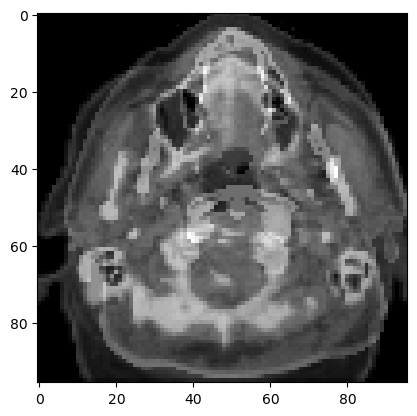

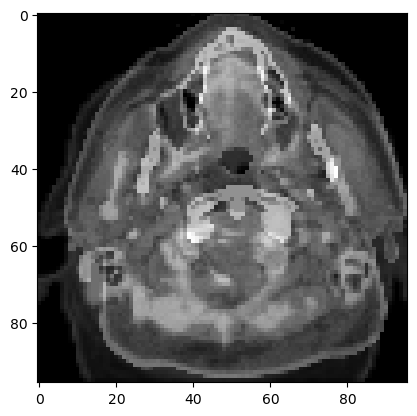

In [ ]:

plt.imshow(inputs[0][0][80].cpu().numpy(), cmap='gray')
plt.show()

plt.imshow(inputs[1][0][80].cpu().numpy(), cmap='gray')
plt.show()

In [ ]:
config['general']['resultsCurrentDirectory']

'//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/1. MultiTox_HNC/pred_RT_results\\MixUp_figures\\'

In [17]:

def plot_mixup_images_with_IDs(config, plot_inputs, patient_ids):
    """
    Plots the model inputs (CT, RTDOSE, Segmentation) used during training, and saves the figure as a png.
    Args:
        config (dict): configuration object
        plot_inputs (list): list of model input images
        epoch (int): current epoch number
    Returns:
        None
    """

    for patient_idx in range(len(plot_inputs)):
        
        ct_range = (config['data']['preprocessing']['ct']['a_max'] - config['data']['preprocessing']['ct']['a_min'])
        rtdose_range = (config['data']['preprocessing']['rtdose']['a_max'] - config['data']['preprocessing']['rtdose']['a_min'])
        
        CT = (plot_inputs[patient_idx][0].cpu() * ct_range) + config['data']['preprocessing']['ct']['a_min']
        RTDOSE = plot_inputs[patient_idx][1].cpu() * rtdose_range + config['data']['preprocessing']['rtdose']['a_min']
        RTSTRUCT = plot_inputs[patient_idx][2].cpu()

        plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE
            },
            {
                "Label": "RTSTRUCT",
                "RTSTRUCT": RTSTRUCT
            }
        ]

        num_CT_slices = CT.shape[0]
        num_plot_slices = config['saving']['plot_training_slices']['n_slices_per_patient']

        slices = list(range(0, num_CT_slices, num_CT_slices // (num_plot_slices + 1)))[1:-1]

        #slices = [20, 30, 40, 50, 60, 70, 80, 90]
        fig, axes = plot_slices(plotting_rows_dicts, slices, RT_region=config['general']['region'])# , title=f"{patient_id} slices")


        ID1 = patient_ids[patient_idx]
        ID2 = patient_ids[indices[patient_idx]]

        filename=os.path.join(config['general']['resultsCurrentDirectory'], '{}_{}_{}.png'.format(ID1, ID2, round(lamb, 3)))
        #print(filename)
        fig.savefig(filename, bbox_inches='tight')
        plt.close(fig)
        plt.close('all')
        


def plot_normal_model_inputs(config, plot_inputs, patient_ID):
    """
    Plots the model inputs (CT, RTDOSE, Segmentation) used during training, and saves the figure as a png.
    Args:
        config (dict): configuration object
        plot_inputs (list): list of model input images
        epoch (int): current epoch number
    Returns:
        None
    """
    # check that the directory exists
    save_folder = os.path.join(config['general']['resultsCurrentDirectory'], config['saving']['plot_training_slices']['folder_name'])
    if not os.path.exists(save_folder):
        os.makedirs(save_folder, exist_ok=True)


    for patient_idx in range(len(plot_inputs)):
        
        ct_range = (config['data']['preprocessing']['ct']['a_max'] - config['data']['preprocessing']['ct']['a_min'])
        rtdose_range = (config['data']['preprocessing']['rtdose']['a_max'] - config['data']['preprocessing']['rtdose']['a_min'])
        
        CT = (plot_inputs[patient_idx][0].cpu() * ct_range) + config['data']['preprocessing']['ct']['a_min']
        RTDOSE = plot_inputs[patient_idx][1].cpu() * rtdose_range + config['data']['preprocessing']['rtdose']['a_min']
        RTSTRUCT = plot_inputs[patient_idx][2].cpu()

        plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE
            },
            {
                "Label": "RTSTRUCT",
                "RTSTRUCT": RTSTRUCT
            }
        ]

        num_CT_slices = CT.shape[0]
        num_plot_slices = config['saving']['plot_training_slices']['n_slices_per_patient']

        slices = list(range(0, num_CT_slices, num_CT_slices // (num_plot_slices + 1)))[1:-1]

        #slices = [20, 30, 40, 50, 60, 70, 80, 90]
        fig, axes = plot_slices(plotting_rows_dicts, slices, RT_region=config['general']['region'])# , title=f"{patient_id} slices")

        ID1 =patient_ID

        filename=os.path.join(save_folder, '{}.png'.format(ID1))
        #print(filename)
        fig.savefig(filename, bbox_inches='tight')
        plt.close(fig)
        plt.close('all')